In [1]:
%reload_ext autoreload
%autoreload 2

# import all the functions from the fastfeedback module
from fastfeedback import *

In [2]:
#Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum_weighted.root")

Loading data...


/software/oz22897/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


In [3]:
#Preparing the data with the default settings, of the current reco performances
data = data_manager.prepare_data()

#Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

#Creating the events distribution
events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


In [25]:
from tqdm import tqdm

null_hyps = [
    get_nufit(MH.Normal),
    get_nufit(MH.Normal),
    get_nufit(MH.Inverted),
    get_nufit(MH.Inverted)
    ]
null_hyps[0].dcp = 0
null_hyps[1].dcp = np.pi/2
null_hyps[2].dcp = 0
null_hyps[3].dcp = np.pi/2

ref_event_rates = []

for null_hyp in null_hyps:
    events.compute_osc(null_hyp)
    ref_event_rates.append({fl: events.detected_events(fl) for fl in events.detected_channels})

LnL_values_nofit = [[] for _ in range(len(null_hyps))]
dcp_scan = np.linspace(-np.pi, np.pi, 40)
for dcp in tqdm(dcp_scan):
    alt_hyp = get_nufit(MH.Normal)
    alt_hyp.dcp = dcp

    events.compute_osc(alt_hyp)

    expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

    for i, null_hyp in enumerate(null_hyps):
        #Computing the LnL values
        llh = 0
        for ch in events.detected_channels:
            llh += LnL(ref_event_rates[i][ch], expected[ch])
        LnL_values_nofit[i].append(llh)


100%|██████████| 40/40 [00:15<00:00,  2.53it/s]


In [26]:
from tqdm import tqdm

#Gets the standard oscillation parameters
pars = get_nufit(MH.Normal)
#Compute the events with the standard oscillation parameters
events.compute_osc(pars)
#Saving the reference event rates
ref_event_rates = {fl: events.detected_events(fl) for fl in events.detected_channels}

LnL_values = {fl: [] for fl in events.detected_channels}

#Sampling dcp values
sampling = np.linspace(0, 2*np.pi, 50)
for val in tqdm(sampling):
    #Setting the dcp value
    pars.dcp = val
    #Computing the events with the new dcp value
    events.compute_osc(pars)
    #Saving the expected event rates
    expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

    #Computing the LnL values
    for ch in events.detected_channels:
        LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

#Converting the lists to numpy arrays
LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

100%|██████████| 50/50 [00:15<00:00,  3.14it/s]


In [27]:
import iminuit
from iminuit import Minuit

def loss(dm21, dm31, th12, th13, th23, dcp):
    pars = ROOT.OscPars()
    pars.dm21 = dm21
    pars.dm31 = dm31
    pars.th12 = th12
    pars.th13 = th13
    pars.th23 = th23
    pars.dcp  = dcp
    
    events.compute_osc(pars)
    #Saving the expected event rates
    expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
    total_loss = 0
    for ch in events.detected_channels:
        total_loss += LnL(ref_event_rates[ch], expected[ch])
    # print(total_loss)
    return total_loss

nufit = get_nufit(MH.Normal)

fitter = iminuit.Minuit(loss, dm21=nufit.dm21, dm31=nufit.dm31, th12=nufit.th12, th13=nufit.th13, th23=nufit.th23, dcp=nufit.dcp)

In [28]:
fitter.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 78               │
│ EDM = 1.28e-16 (Goal: 0.0002)    │           time = 24.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ dm21 │  0.07e-3  │  0.08e-3  │            │            │         │         │       │
│ 1 │ dm31 │  2.46e-3  │  0.06e-3  │            │            │         │         │       │
│ 2 │ th12 │    0.6    │    0.5    │            │            │         │         │       │
│ 3 │ th13 │   0.15    │   0.05    │            │            │         │         │       │
│ 4 │ th23 │   0.737   │   0.034   │            │            │         │         │       │
│ 5 │ dcp  │    5.3    │    0.7    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬───────────────────────────────────────────────────────────────────┐
│      │       dm21       dm31       th12       th13       th23        dcp │
├──────┼───────────────────────────────────────────────────────────────────┤
│ dm21 │   6.29e-09       3e-9   7.302e-6    -673e-9     474e-9  18.080e-6 │
│ dm31 │       3e-9   3.59e-09 -15.742e-6    -789e-9     743e-9  24.401e-6 │
│ th12 │   7.302e-6 -15.742e-6      0.287     0.0034    -0.0071      -0.19 │
│ th13 │    -673e-9    -789e-9     0.0034    0.00297    -0.0001    -0.0144 │
│ th23 │     474e-9     743e-9    -0.0071    -0.0001    0.00117     0.0095 │
│  dcp │  18.080e-6  24.401e-6      -0.19    -0.0144     0.0095      0.456 │
└──────┴───────────────────────────────────────────────────────────────────┘

In [29]:
cheated_params = ["dm21", "dm31", "th12", "th13", "th23"]
dcp_values = []
dcp_errors = []
true_params = get_nufit(MH.Normal)

fitter.fixed = {p: False for p in fitter.parameters}

for param in cheated_params:
    for p in cheated_params: fitter.fixed[p] = False 
    fitter.values[param] = getattr(true_params, param)
    fitter.fixed[param] = True
    fitter.migrad()
    fitter.hesse()
    dcp_values.append(fitter.values["dcp"])
    dcp_errors.append(fitter.errors["dcp"])

for p in cheated_params:
    fitter.values[p] = getattr(true_params, p)
    fitter.fixed[p] = True

fitter.migrad()
fitter.hesse()

labels = cheated_params + ["All Fixed"]
plot_values = dcp_values + [fitter.values["dcp"]]
plot_errors = dcp_errors + [fitter.errors["dcp"]]

KeyboardInterrupt: 

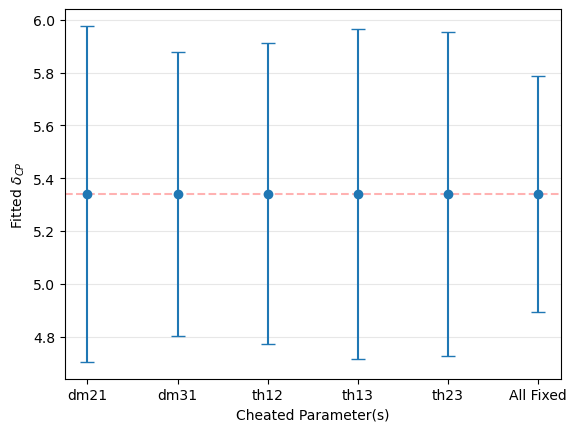

In [ ]:

plt.errorbar(labels, plot_values, yerr=plot_errors,fmt='o', capsize=5)
plt.axhline(5.34, color='red', linestyle='--', alpha=0.3) 
plt.ylabel(r"Fitted $\delta_{CP}$")
plt.xlabel("Cheated Parameter(s)")
plt.grid(axis='y', alpha=0.3)
plt.show()

## Mass year comparison

 Running 5 kt-years
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


 Running 10 kt-years
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


 Running 25 kt-years
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


 Running 50 kt-years
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


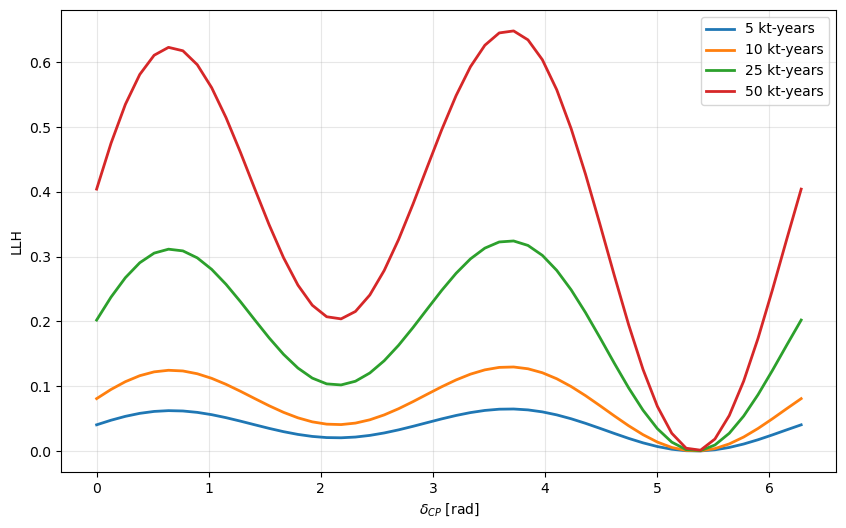

In [5]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

#mass year comparisons

kt_years = [5, 10, 25, 50]
all_results = {}

pars = get_nufit(MH.Normal)
sampling = np.linspace(0, 2 * np.pi, 50)

for kt_yr in kt_years:
    print(f" Running {kt_yr} kt-years")
    
    # To get 50 kt-years of weight, need a multiplier of 50/400
    # Therefore: 400 / exposure_param = kt_yr / 400 hence exposure_param = 160000 / kt_yr
    eff_exposure = 160000.0 / kt_yr
    
    events = EventDistrib(data_manager.prepare_data(), Ebins, Czbins, Ebins_reco, Czbins_reco, 
                          exposure=eff_exposure)
    
    pars.dcp = get_nufit(MH.Normal).dcp 
    events.compute_osc(pars)
    ref_event_rates = {fl: events.detected_events(fl) for fl in events.detected_channels}
    
    LnL_values_list = {fl: [] for fl in events.detected_channels}
    
    for val in tqdm(sampling, leave=False):
        pars.dcp = val
        events.compute_osc(pars)
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        
        for ch in events.detected_channels:
            LnL_values_list[ch].append(LnL(ref_event_rates[ch], expected[ch]))
            
    total_llh = np.zeros(len(sampling))
    for ch in events.detected_channels:
        total_llh += np.array(LnL_values_list[ch])
        
    all_results[kt_yr] = total_llh

plt.figure(figsize=(10, 6))
for kt_yr, llh in all_results.items():
    plt.plot(sampling, llh, label=f"{kt_yr} kt-years", linewidth=2)

plt.xlabel(r"$\delta_{CP}$ [rad]")
plt.ylabel(r"LLH")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()